In [ ]:
import subprocess
import sys

cmd = [
    sys.executable, "run_kfold.py",
    "--results_dir", "kfold_results",
    "--folder_name", "1_layer_handover",
    # "--activation",
    # "--activation_type", "relu",
    "--num_hidden_layers", "0",
    # "--hidden_features", "256,128,64,32",
    # "--loss_fn", "huber",
    # "--huber_delta", "0.01",
    "--epochs", "1000",
    "--batch_size", "8",
    "--lr", "1e-3",
    "--weight_decay", "1e-3",
    "--n_splits", "5",
    "--seed", "0",
]

subprocess.run(cmd, check=True)

In [ ]:
# import subprocess
# import sys

# subprocess.run([sys.executable, 'parallel_folds.py'], check = True)

/data1/soldatr/luan/projects/cell_tissue_phenotype/uv_env/.venv/lib/python3.11/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `multiplicative_replacement` was renamed to `multi_replace` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


[Main] Starting GPU 0 with folds: [1, 3, 5]
[Main] Starting GPU 1 with folds: [2, 4]


 13%|█▎        | 126/1000 [07:35<52:36,  3.61s/it]


[GPU 0] Fold 1: test MSE=0.4549


  0%|          | 3/1000 [00:11<1:04:52,  3.90s/it]

[GPU 1] Fold 2: test MSE=0.4188


  4%|▍         | 45/1000 [02:40<57:37,  3.62s/it]  

In [5]:
import pickle
import os 

filename_pkl = "cuda_parallel"
# results_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/kfold_results'
# folder_name = '4_layers_Huber'

results_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/_hand_over/kfold_results'
folder_name = '1_layer_handover'

fold = 2

file_dir = os.path.join(results_dir, folder_name)
file_path = os.path.join(file_dir, f"{filename_pkl}_fold_{fold}.pkl")


with open(file_path, "rb") as f:
    result = pickle.load(f)

In [7]:
result['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): CellPredictor(
    (network): Sequential(
      (0): Linear(in_features=17450, out_features=16, bias=True)
    )
  )
)

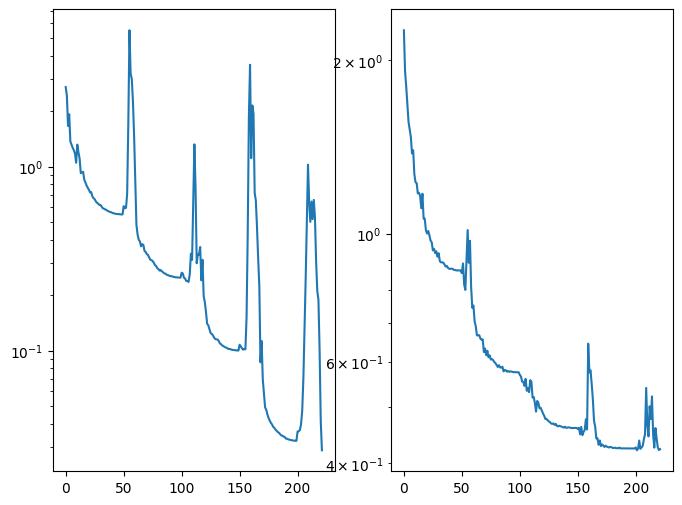

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 6))
plt.subplot(1, 2, 1)
plt.plot(result['train_mse_history'])
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.plot(result['val_mse_history'])
plt.yscale('log')

In [9]:
result.keys()

dict_keys(['fold', 'train_mse_history', 'val_mse_history', 'test_mse', 'cor_list', 'rsq_list', 'test_res', 'trainer'])

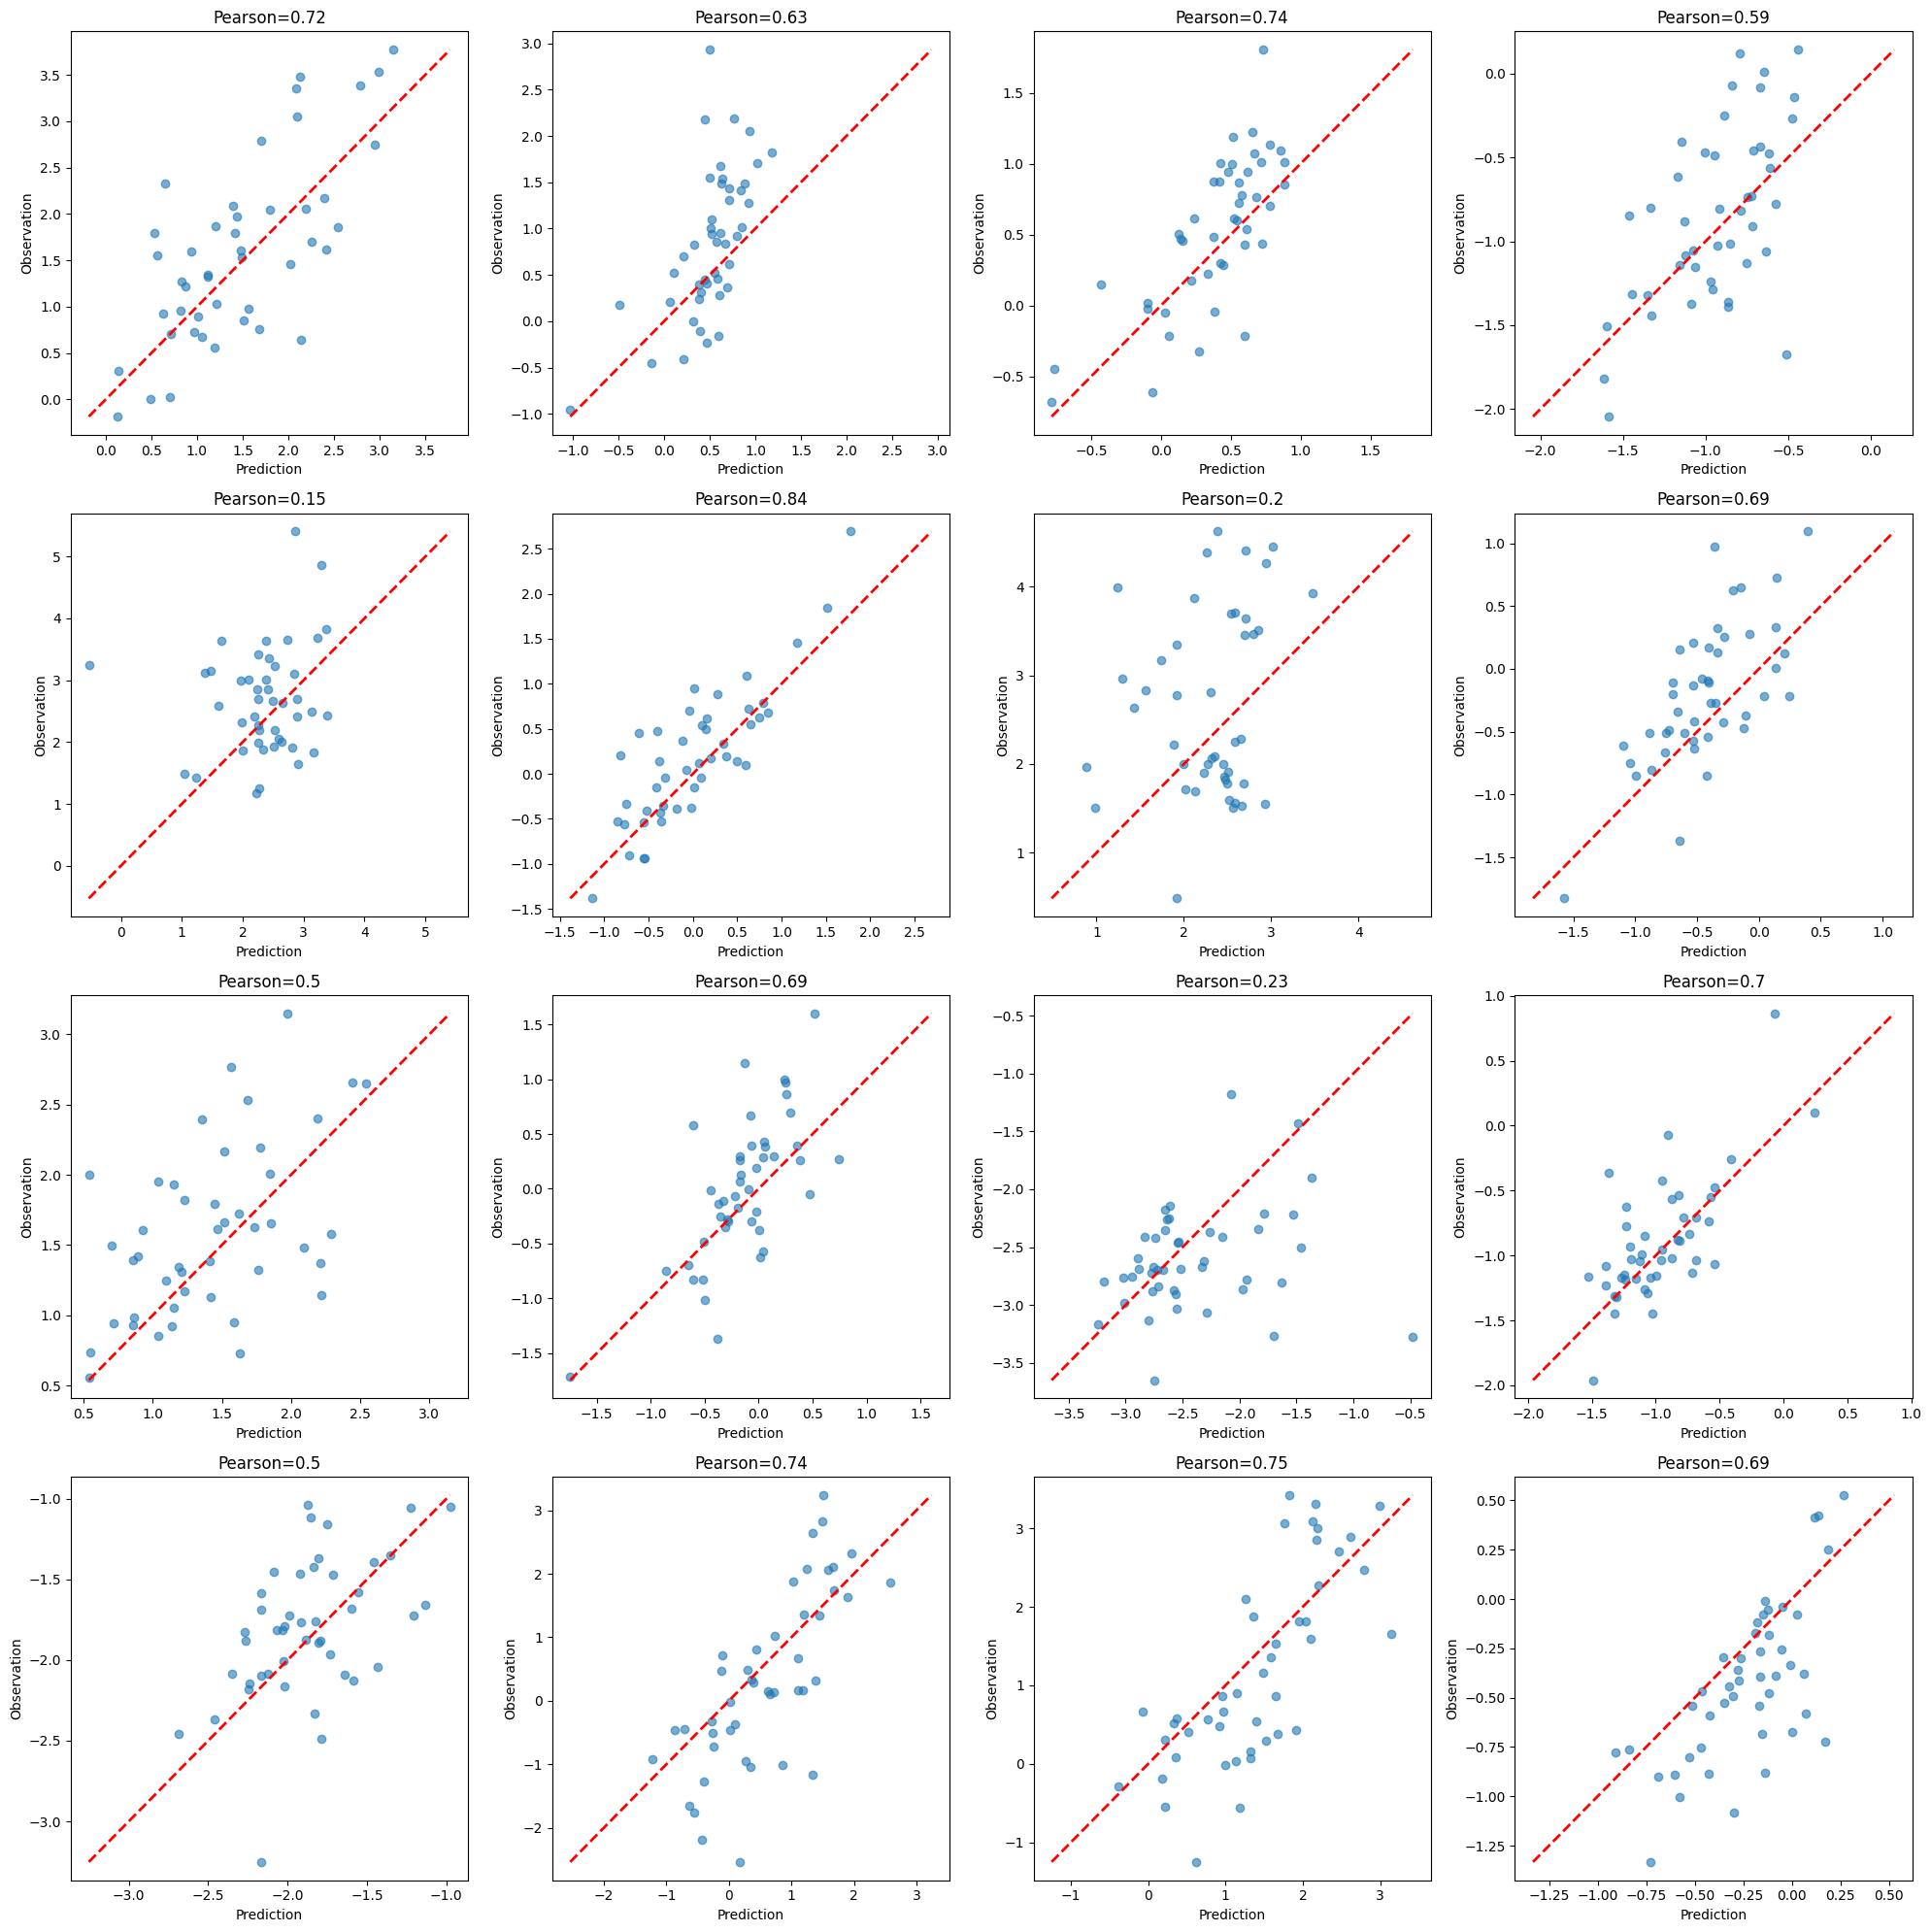

In [11]:
import numpy as np

targets = result['test_res']['targets']
preds = result['test_res']['preds']

test_targets = targets.numpy()
test_preds = preds.numpy()

ncols = 4
nrows = round(test_targets.shape[1]/ncols) 

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(test_targets.shape[1]):
    axs[i].scatter(test_preds[:,i].ravel(), test_targets[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}")
    axs[i].set_title(f"Pearson={np.round(np.corrcoef(test_preds[:, i], test_targets[:, i])[0][1], decimals = 2)}")
    min_val = min(test_preds[:, i].min(), test_targets[:, i].min())
    max_val = max(test_preds[:, i].max(), test_targets[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

In [14]:
import pandas as pd
import os 
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr
import numpy as np

org_dir = "/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/refined/"
method = "max_counts"

cell_type_proportions_df = pd.read_csv(
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/cell_type_proportions_harmony_sample_id.csv",
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/cell_type_proportions_harmony_sample_id_avg_pseudobulk.csv",
        # "/data1/soldatr/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/max_counts/parallel/cell_type_proportions_pseudobulk_max_counts.csv",
        # "/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/weighted_ncells/cell_type_proportions_pseudobulk_max_counts.csv",
        os.path.join(org_dir, f"{method}/mean_gene_expression/cell_type_proportions_pseudobulk_{method}.csv"),
        index_col=0
    )

meta = pd.read_csv("/home/lel2/luan/projects/cell_tissue_phenotype/results/normal_HSC/pseudobulk/refined/max_counts/mean_gene_expression/metadata_samples_pseudobulk_max_counts.csv")

assert(np.all(cell_type_proportions_df.index == meta["sample_id"]))

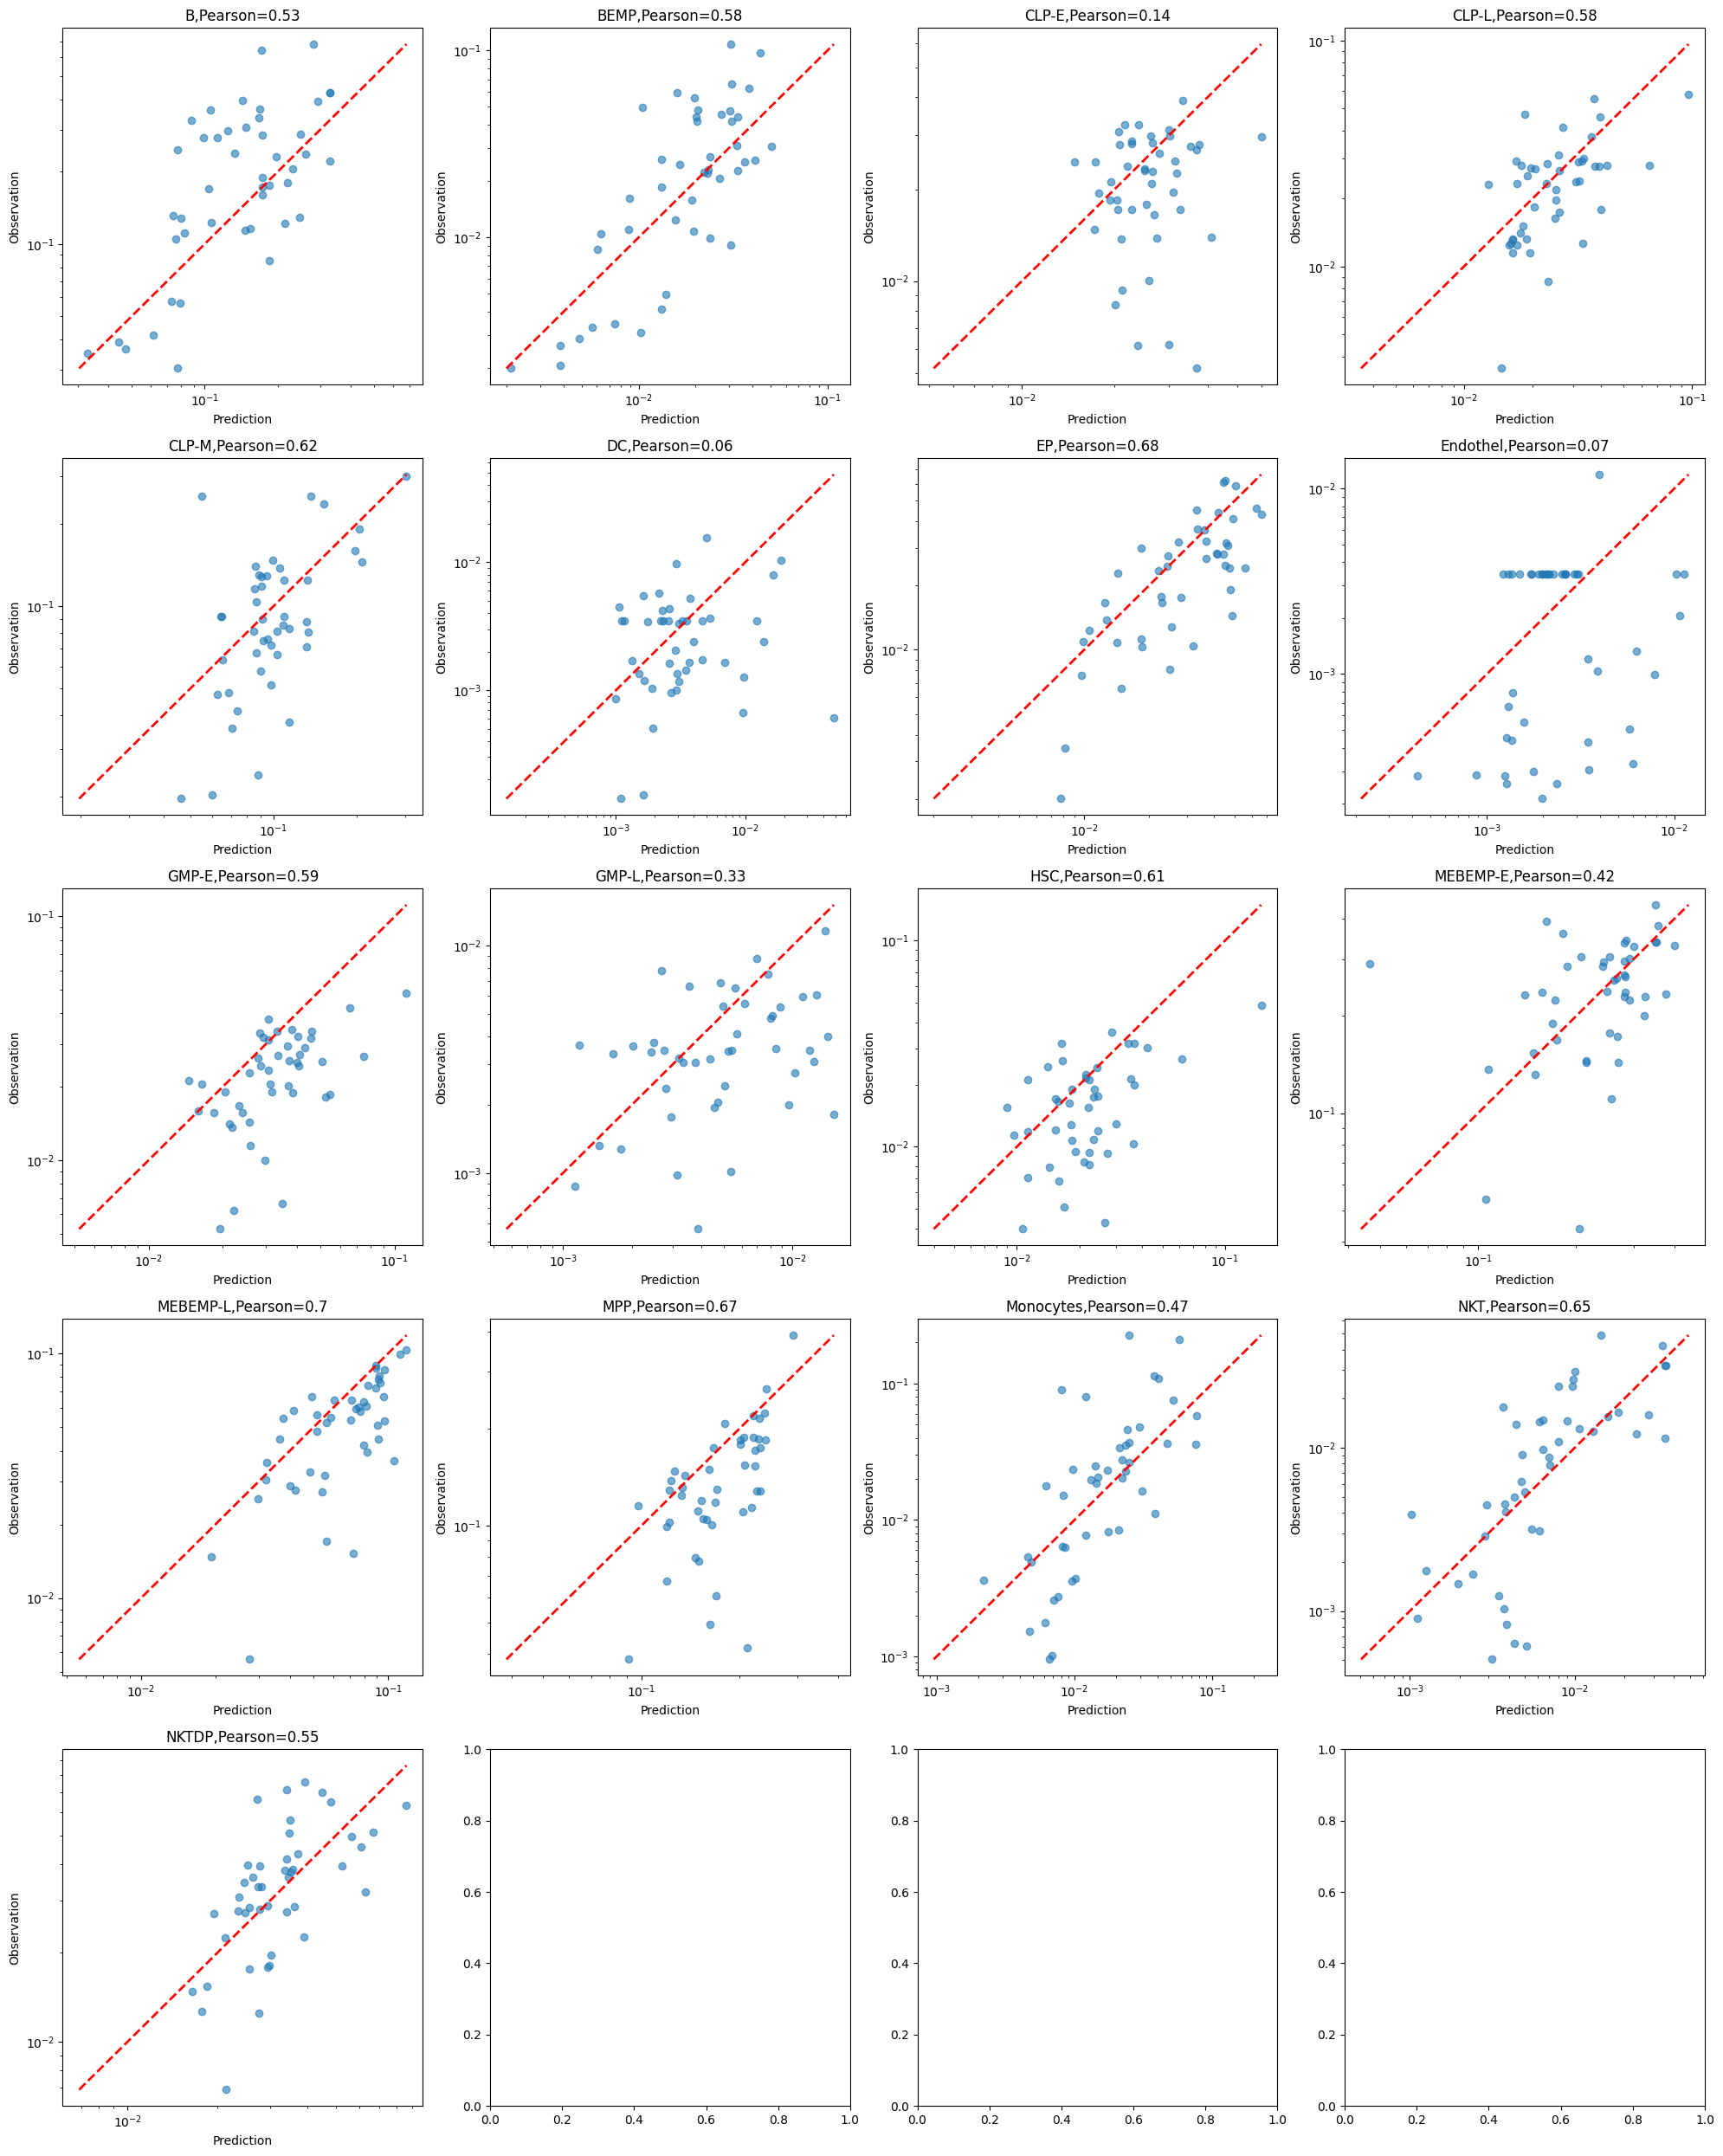

In [15]:

ncols = 4
nrows = round(test_targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(test_preds)
ct_obs = ilr_inv(test_targets)

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]},Pearson={np.round(np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1], decimals = 2)}")

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

In [16]:
import pickle
import os
from skbio.stats.composition import ilr, ilr_inv, clr
import numpy as np


def get_correlation(pred: np.ndarray, obs:np.ndarray):        
    cor_list = [np.corrcoef(pred[:, i], obs[:, i], rowvar=False)[0][1] for i in range(pred.shape[1])]
    return cor_list

def dict_to_df(d: dict[str, np.ndarray]) -> pd.DataFrame:
    max_length = max([len(d[k]) for k in d.keys()])
    M = np.full((max_length, len(d.keys())), np.nan, dtype = np.float32)
    for j, k in enumerate(d.keys()):        
        M[:len(d[k]), j] = d[k]
    M = pd.DataFrame(M, columns = d.keys())
    return M
        

In [17]:
ilr_by_fold = {}
clr_by_fold = {}
celltype_by_fold = {}
nfolds = 5

filename_pkl = "cuda_parallel"
# results_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/kfold_results'
# folder_name = '4_layers_Huber'
# folder_name = '4_layers_L1'

results_dir = '/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/_hand_over/kfold_results'
folder_name = '1_layer_handover'

file_dir = os.path.join(results_dir, folder_name)

for fold in np.arange(start = 1, stop = nfolds+1):
    
    file_path = os.path.join(file_dir, f"{filename_pkl}_fold_{fold}.pkl")

    with open(file_path, 'rb') as f:
        result = pickle.load(f)

    targets = result['test_res']['targets']
    preds = result['test_res']['preds']
    
    test_targets = targets.numpy()
    test_preds = preds.numpy()

    ct_preds = ilr_inv(test_preds)
    ct_obs = ilr_inv(test_targets)

    ilr_cor_list = get_correlation(test_preds, test_targets)
    clr_cor_list = get_correlation(clr(ct_preds), clr(ct_obs))
    celltype_cor_list = get_correlation(ct_preds, ct_obs)

    ilr_by_fold[f"fold_{fold}"] = ilr_cor_list
    clr_by_fold[f"fold_{fold}"] = clr_cor_list
    celltype_by_fold[f"fold_{fold}"] = celltype_cor_list

In [18]:
clr_df = dict_to_df(clr_by_fold)
celltype_df = dict_to_df(celltype_by_fold)

celltype_df['cors_comp_mean_MLP'] = celltype_df.mean(axis = 1)
celltype_df['cors_comp_std_MLP'] = celltype_df.std(axis = 1)
celltype_df['celltype'] = cell_type_proportions_df.columns.tolist()

clr_df['cors_clr_mean_MLP'] = clr_df.mean(axis = 1)
clr_df['cors_clr_std_MLP'] = clr_df.std(axis = 1)
clr_df['celltype'] = cell_type_proportions_df.columns.tolist()

In [29]:
ilr_df = dict_to_df(ilr_by_fold)
ilr_df.head()

,fold_1,fold_2,fold_3,fold_4,fold_5
0,0.804272,0.721625,0.615480,0.660051,0.778409
1,0.631259,0.627962,0.637607,0.679051,0.482726
2,0.587837,0.740377,0.591737,0.820404,0.401525
3,0.592439,0.592887,0.387245,0.456816,0.519610
4,0.267603,0.149732,0.378357,0.270698,0.195495


In [27]:
import pickle

with open("/data1/soldatr/luan/projects/cell_tissue_phenotype/scripts/deep_learning/HSC_MPP_regression.pkl", "rb") as f:
    HSC_MPP_regression = pickle.load(f)

# with open("B_regression.pkl", "rb") as f:
#     HSC_MPP_regression = pickle.load(f)
    
# metrics = ['cors_comp']
metrics = ['cors_clr_comp', 'cors_comp']
all_rows_linear = []
nfolds = 5

pseudobulk_ilr = {}

for fold in np.arange(nfolds):
    fitting_res_dict = HSC_MPP_regression[fold+1]    
  
    K = celltype_df.shape[0]
    celltypes = cell_type_proportions_df.columns.tolist()
    assert K == len(celltypes), "Mismatch between metrics length and number of cell types"

    for i in range(K):
        row = {
            'fold': fold,
            'celltype': celltypes[i],
        }
        for m in metrics:
            row[m] = fitting_res_dict[m][i]
        all_rows_linear.append(row)

     # doing for ilr
    test_ilr = ilr(fitting_res_dict['Y_test_comp_df'])
    obs_ilr = ilr(fitting_res_dict['Y_obs_comp_df'])
    pseudobulk_ilr[f'fold_{fold+1}'] = [np.corrcoef(test_ilr[:, i], obs_ilr[:, i], rowvar = False)[0][1] for i in range(test_ilr.shape[1])]


df_long_linear = pd.DataFrame(all_rows_linear)
print(df_long_linear.head())


   fold celltype  cors_clr_comp  cors_comp
0     0        B       0.551128   0.644776
1     0     BEMP       0.722919   0.687946
2     0    CLP-E       0.542364   0.438066
3     0    CLP-L       0.742041   0.624261
4     0    CLP-M       0.653651   0.735733


/tmp/ipykernel_3717357/540023048.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[m] = fitting_res_dict[m][i]


In [28]:
ilr_pseudobulk_df = dict_to_df(pseudobulk_ilr)
ilr_pseudobulk_df.head()

,fold_1,fold_2,fold_3,fold_4,fold_5
0,0.677066,0.705839,0.677189,0.744283,0.722544
1,0.621956,0.589788,0.633634,0.602148,0.611477
2,0.812182,0.604449,0.670527,0.734939,0.662202
3,0.712779,0.781752,0.626986,0.700797,0.634695
4,0.314376,0.084459,0.431053,0.486972,0.084138


In [21]:
# 1) group and aggregate
agg_linear = df_long_linear.groupby('celltype')[metrics].agg(['mean', 'std', 'count']).reset_index()

# 2) flatten MultiIndex columns
agg_linear.columns = ['celltype'] + [f"{metric}_{stat}" for metric, stat in agg_linear.columns[1:]]


  celltype  cors_clr_comp_mean  cors_clr_comp_std  cors_clr_comp_count  \
0        B            0.568724           0.040875                    5   
1     BEMP            0.758180           0.045727                    5   
2    CLP-E            0.504883           0.079246                    5   
3    CLP-L            0.686519           0.071266                    5   
4    CLP-M            0.672702           0.100187                    5   

   cors_comp_mean  cors_comp_std  cors_comp_count  cors_clr_comp_sem  \
0        0.566874       0.091041                5           0.018280   
1        0.653459       0.052678                5           0.020450   
2        0.470071       0.083666                5           0.035440   
3        0.627940       0.047539                5           0.031871   
4        0.708376       0.082376                5           0.044805   

   cors_clr_comp_95ci_lower  cors_clr_comp_95ci_upper  cors_comp_sem  \
0                  0.532895                  0.604

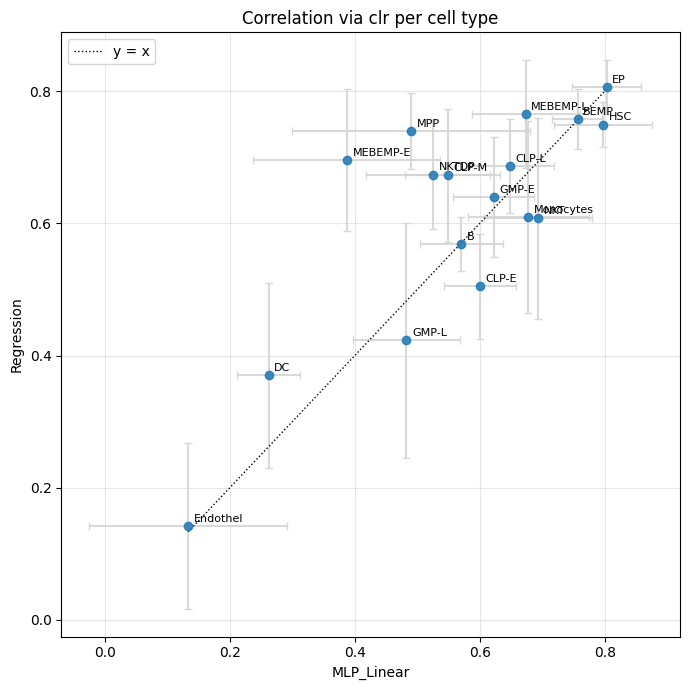

In [22]:

# 3) compute SEM and 95% CI (using normal approx; adjust if n small)
for m in metrics:
    mean_col = f"{m}_mean"
    std_col = f"{m}_std"
    cnt_col = f"{m}_count"
    sem_col = f"{m}_sem"
    ci_lo = f"{m}_95ci_lower"
    ci_hi = f"{m}_95ci_upper"

    # SEM: std / sqrt(n) (if count is 0, result becomes NaN)
    agg_linear[sem_col] = agg_linear[std_col] / np.sqrt(agg_linear[cnt_col].replace(0, np.nan))

    # 95% CI using 1.96 * SEM (normal approx)
    agg_linear[ci_lo] = agg_linear[mean_col] - 1.96 * agg_linear[sem_col]
    agg_linear[ci_hi] = agg_linear[mean_col] + 1.96 * agg_linear[sem_col]

# Example: show the table
print(agg_linear.head())


# python
# Plot error-scatter between two dataframes (agg, agg_linear) for cell-type correlations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: try to find error columns for a mean column ----------
def _find_error_columns(df, mean_col):
    """
    Given df and mean_col (e.g., 'clr_cor_t_mean'), try to find:
      - symmetric error column (std or sem) -> returns ('sym', colname) or None
      - asymmetric CI columns (lower, upper) -> returns ('asym', (low_col, up_col)) or None
    """
    # candidates for symmetric error
    sym_candidates = [
        mean_col.replace('_mean', '_std'),
        mean_col.replace('_mean', '_sem'),
        mean_col + '_std',
        mean_col + '_sem'
    ]
    for c in sym_candidates:
        if c in df.columns:
            return ('sym', c)

    # candidates for asymmetric CI (lower/upper)
    low_candidates = [
        mean_col.replace('_mean', '_95ci_lower'),
        mean_col.replace('_mean', '_ci_lower'),
        mean_col + '_95ci_lower',
    ]
    up_candidates = [
        mean_col.replace('_mean', '_95ci_upper'),
        mean_col.replace('_mean', '_ci_upper'),
        mean_col + '_95ci_upper',
    ]
    for low in low_candidates:
        for up in up_candidates:
            if low in df.columns and up in df.columns:
                return ('asym', (low, up))

    # nothing found
    return (None, None)

def _get_errors_from_df(df, mean_col):
    """
    Returns either:
      - None, None if no error info
      - symmetric_errors (1d numpy array), None
      - None, asymmetric_errors (2 x N numpy array: [lower, upper])
    Lower/upper are positive distances from the mean.
    """
    typ, col = _find_error_columns(df, mean_col)
    mean_vals = df[mean_col].to_numpy(dtype=float)

    if typ == 'sym':
        sym = df[col].to_numpy(dtype=float)
        # Ensure non-negative
        sym = np.maximum(sym, 0.0)
        return sym, None
    elif typ == 'asym':
        low_col, up_col = col
        low = df[low_col].to_numpy(dtype=float)
        up = df[up_col].to_numpy(dtype=float)
        # Convert to distances from mean (in case columns were absolute bounds)
        lower_err = np.clip(mean_vals - low, 0.0, None)
        upper_err = np.clip(up - mean_vals, 0.0, None)
        return None, np.vstack([lower_err, upper_err])
    else:
        return None, None

# ---------- Main plotting function ----------
def plot_error_scatter(agg, agg_linear,
                       mean_col1='clr_cor_t_mean',
                       mean_col2='cors_clr_comp_mean',
                       celltype_col='celltype',
                       title='Correlation per cell type',
                       annotate=True,
                       figsize=(7,7),
                       savepath=None):
    """
    Merge agg and agg_linear on celltype_col and plot mean_col1 (x) vs mean_col2 (y)
    with error bars if available.
    Returns merged DataFrame and the matplotlib Figure.
    """
    # merge
    merged = pd.merge(agg, agg_linear, on=celltype_col, how='inner', suffixes=('_pytorch','_analytical'))
    if mean_col1 not in merged.columns:
        raise KeyError(f"{mean_col1} not found in merged dataframe columns: {merged.columns.tolist()}")
    if mean_col2 not in merged.columns:
        raise KeyError(f"{mean_col2} not found in merged dataframe columns: {merged.columns.tolist()}")

    # drop rows with NaN in mean cols
    merged = merged.dropna(subset=[mean_col1, mean_col2]).reset_index(drop=True)

    x = merged[mean_col1].to_numpy(dtype=float)
    y = merged[mean_col2].to_numpy(dtype=float)

    # errors for x and y (symmetric or asymmetric)
    x_sym, x_asym = _get_errors_from_df(merged, mean_col1)
    y_sym, y_asym = _get_errors_from_df(merged, mean_col2)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    # Choose errorbar parameters depending on availability
    err_kwargs = {}
    if x_asym is not None:
        err_kwargs['xerr'] = x_asym
    elif x_sym is not None:
        err_kwargs['xerr'] = x_sym
    if y_asym is not None:
        err_kwargs['yerr'] = y_asym
    elif y_sym is not None:
        err_kwargs['yerr'] = y_sym

    # Basic scatter with error bars (if any)
    ax.errorbar(x, y, fmt='o', ecolor='lightgray', alpha=0.85, capsize=3, markersize=6, **err_kwargs)

    # diagonal and fit line
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    low = min(xmin, ymin)
    high = max(xmax, ymax)
    line_x = np.linspace(low, high, 200)
    ax.plot(line_x, line_x, color='k', linestyle=':', linewidth=1, label='y = x')
    # if not np.isnan(m):
    #     ax.plot(line_x, m*line_x + b, color='C1', linestyle='--', linewidth=1, label=f'fit: y={m:.2f}x+{b:.2f}')

    # annotations
    if annotate:
        for xi, yi, label in zip(x, y, merged[celltype_col].astype(str)):
            ax.annotate(label, (xi, yi), xytext=(4, 3), textcoords='offset points', fontsize=8)
    if mean_col1 in (['cors_clr_mean_MLP', 'cors_comp_mean_MLP']):
        ax.set_xlabel("MLP_Linear")
    else:
        ax.set_xlabel(mean_col1)

    if mean_col2 in (['cors_clr_comp_mean', 'Rsq_clr_comp_mean']):
        ax.set_ylabel("Regression")
    else:
        ax.set_ylabel(mean_col2)
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    # show pearson text
    # ax.text(0.02, 0.98, pearson_text, transform=ax.transAxes, va='top', fontsize=9)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300)

    return merged, fig

# ---------- Example usage ----------
merged_df, fig = plot_error_scatter(clr_df, agg_linear,
                                   mean_col1='cors_clr_mean_MLP',
                                   mean_col2='cors_clr_comp_mean',
                                   celltype_col='celltype',
                                   title='Correlation via clr per cell type',
                                   annotate=True,
                                   savepath=None)
plt.show()

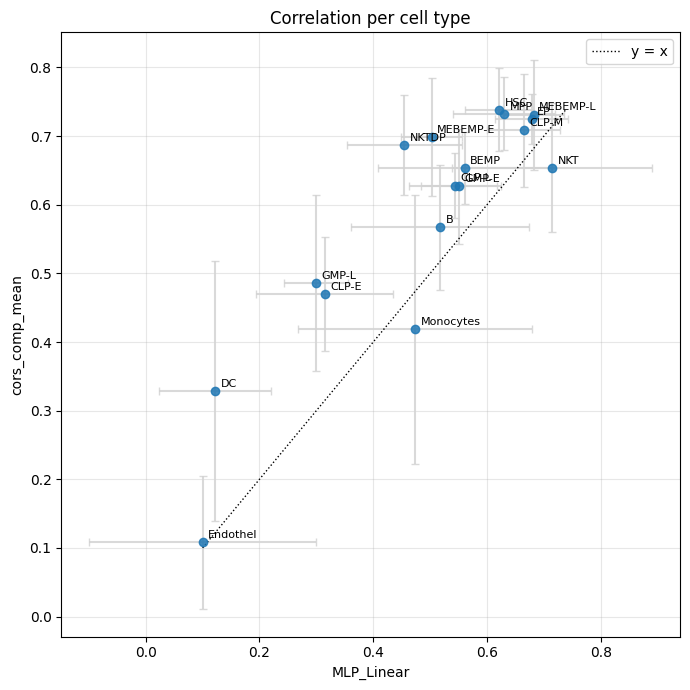

In [23]:
merged_df, fig = plot_error_scatter(celltype_df, agg_linear,
                                   mean_col1='cors_comp_mean_MLP',
                                   mean_col2='cors_comp_mean',
                                   celltype_col='celltype',
                                   title='Correlation per cell type',
                                   annotate=True,
                                   savepath=None)
plt.show()

In [ ]:
# plot ilr comparison

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_row_mean_ci(df: pd.DataFrame, fold_cols: list[str], alpha: float = 0.05):
    """
    Compute per-row mean, std, count, SEM and 95% CI over fold columns.
    Returns a DataFrame with columns: ['mean', 'std', 'count', 'sem', 'ci_lower', 'ci_upper'].
    """
    # Coerce selected columns to numeric, invalid strings -> NaN
    df_numeric = df[fold_cols].apply(pd.to_numeric, errors="coerce")

    # Count non-NaN entries per row
    count = df_numeric.notna().sum(axis=1).astype(int)
    # Mean/std across folds (ignore NaNs). Use ddof=1 for sample std if count>1.
    mean = df_numeric.mean(axis=1, skipna=True)
    std = df_numeric.std(axis=1, ddof=1, skipna=True)

    # SEM = std / sqrt(n); NaN where n<=1
    sem = std / np.sqrt(count.replace(0, np.nan))

    # 95% CI: mean ± tcrit * sem if possible; else normal approx
    try:
        from scipy.stats import t
        # t critical per row: handle n<=1 -> NaN
        dfree = (count - 1).astype(float)
        tcrit = pd.Series(np.nan, index=df.index)
        ok = dfree > 0
        tcrit.loc[ok] = t.ppf(1 - alpha/2, df=dfree[ok])
        ci_lower = mean - tcrit * sem
        ci_upper = mean + tcrit * sem
    except ImportError:
        # Fallback to normal approx 1.96
        z = 1.96
        ci_lower = mean - z * sem
        ci_upper = mean + z * sem

    return pd.DataFrame({
        "mean": mean,
        "std": std,
        "count": count,
        "sem": sem,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }, index=df.index)

def plot_fold_mean_ci_compare(ilr_pseudobulk_df: pd.DataFrame,
                              ilr_df: pd.DataFrame,
                              fold_cols: list[str] = None,
                              label_col: str | None = None,
                              title: str = "Fold-wise mean and 95% CI: pseudobulk (y) vs linear (x)",
                              annotate: bool = True,
                              figsize=(7, 7),
                              savepath: str | None = None):
    """
    Compute per-row mean and 95% CI in two dataframes, then plot a scatter:
      x = ilr_df mean (with its 95% CI as x-error)
      y = ilr_pseudobulk_df mean (with its 95% CI as y-error)

    - If label_col is provided, merge on that column; else align by index.
    - Returns merged summary DataFrame and the matplotlib Figure/Axes.
    """
    # Default fold columns: any column matching 'fold_' prefix
    if fold_cols is None:
        fold_cols_ilr = [c for c in ilr_df.columns if str(c).startswith("fold_")]
        fold_cols_pseudo = [c for c in ilr_pseudobulk_df.columns if str(c).startswith("fold_")]
    else:
        fold_cols_ilr = fold_cols
        fold_cols_pseudo = fold_cols

    # Compute summaries
    sum_ilr   = compute_row_mean_ci(ilr_df, fold_cols_ilr)
    sum_pseudo= compute_row_mean_ci(ilr_pseudobulk_df, fold_cols_pseudo)

    # Attach labels for merging if provided
    if label_col is not None:
        if label_col not in ilr_df.columns or label_col not in ilr_pseudobulk_df.columns:
            raise KeyError(f"label_col '{label_col}' not found in both dataframes.")
        sum_ilr = sum_ilr.join(ilr_df[[label_col]])
        sum_pseudo = sum_pseudo.join(ilr_pseudobulk_df[[label_col]])
        merged = pd.merge(sum_ilr, sum_pseudo, on=label_col, suffixes=("_x", "_y"))
        labels = merged[label_col].astype(str).tolist()
    else:
        # Align by index
        merged = sum_ilr.join(sum_pseudo, lsuffix="_x", rsuffix="_y")
        labels = [str(idx) for idx in merged.index]

    # Extract values
    x_mean = merged["mean_x"].to_numpy(dtype=float)
    y_mean = merged["mean_y"].to_numpy(dtype=float)
    # Errors: use asymmetric (lower/upper as distances from mean)
    xerr = np.vstack([
        np.clip(x_mean - merged["ci_lower_x"].to_numpy(dtype=float), 0.0, None),
        np.clip(merged["ci_upper_x"].to_numpy(dtype=float) - x_mean, 0.0, None)
    ])
    yerr = np.vstack([
        np.clip(y_mean - merged["ci_lower_y"].to_numpy(dtype=float), 0.0, None),
        np.clip(merged["ci_upper_y"].to_numpy(dtype=float) - y_mean, 0.0, None)
    ])

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(x_mean, y_mean, xerr=xerr, yerr=yerr, fmt="o",
                ecolor="gray", elinewidth=1, capsize=3, color="tab:blue", alpha=0.9)

    # Diagonal y=x reference
    lo = np.nanmin([np.nanmin(x_mean - xerr[0]), np.nanmin(y_mean - yerr[0])])
    hi = np.nanmax([np.nanmax(x_mean + xerr[1]), np.nanmax(y_mean + yerr[1])])
    pad = 0.05 * (hi - lo) if np.isfinite(hi - lo) else 1.0
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", lw=1, color="k", alpha=0.6)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    # Optional annotations
    if annotate:
        for xi, yi, lab in zip(x_mean, y_mean, labels):
            if np.isfinite(xi) and np.isfinite(yi):
                ax.text(xi, yi, f" {lab}", fontsize=8, va="center", ha="left")

    # Pearson between means
    mask = np.isfinite(x_mean) & np.isfinite(y_mean)
    if mask.sum() >= 2:
        xm = x_mean[mask] - x_mean[mask].mean()
        ym = y_mean[mask] - y_mean[mask].mean()
        denom = np.sqrt((xm**2).sum() * (ym**2).sum())
        r = float((xm * ym).sum() / denom) if denom != 0 else np.nan
        ax.set_title(f"{title}\nPearson r = {r:.3f}")
    else:
        ax.set_title(title)

    ax.set_xlabel("MLP_Linear")
    ax.set_ylabel("Regression")
    ax.grid(True, alpha=0.2)

    if savepath:
        fig.tight_layout()
        fig.savefig(savepath, dpi=150)
    else:
        fig.tight_layout()
        plt.show()

    return merged, (fig, ax)

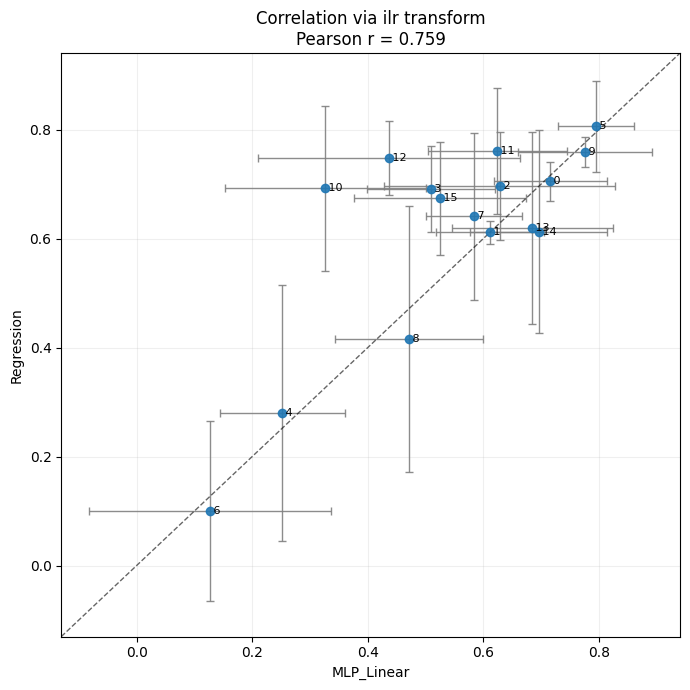

In [30]:
merged, (fig, ax) = plot_fold_mean_ci_compare(ilr_pseudobulk_df, ilr_df, title="Correlation via ilr transform")

# use json results for composition (Still under test)


In [32]:
import json, pickle

pkl_path = "kfold_results_quicktest/fold_1_test_res.pkl"
with open(pkl_path, "rb") as f:
    test_res = pickle.load(f)  # Python dict

In [1]:
import json, glob, os
with open(os.path.join("kfold_results", "summary.json")) as f:
    print(json.load(f))
# Or read per-fold JSONs
cor_list = []
for jf in glob.glob("kfold_results/fold_*_gpu_*.json"):
    with open(jf) as f:
        # print(json.load(f))
        d = json.load(f)
        cor_list.append(d['cor_list'])
    

{'n_folds': 5, 'test_mse_mean': 0.4881001353263855, 'test_mse_std': 0.07462286001451401}


In [3]:
# -*- coding: utf-8 -*-
# Aggregate per-fold correlation vectors into a matrix with columns = folds,
# then compute row-wise mean and std across folds.

import os
import re
import glob
import json
import numpy as np
import pandas as pd  # optional, only used for nicer display/CSV saving

# -----------------------------
# Helper: extract fold number from filename
# -----------------------------
def extract_fold_num(path: str) -> int:
    # Matches ".../fold_3_gpu_0.json" -> 3
    m = re.search(r"fold_(\d+)", os.path.basename(path))
    return int(m.group(1)) if m else 0

# -----------------------------
# Helper: load and sanitize one cor_list
# -----------------------------
def load_cor_list(json_path: str) -> np.ndarray:
    with open(json_path, "r") as f:
        d = json.load(f)
    cor = d.get("cor_list", None)
    if cor is None:
        raise KeyError(f"'cor_list' not found in {json_path}")
    # Replace None with np.nan to avoid JSON null issues, ensure float dtype
    cor = np.array([np.nan if (x is None) else float(x) for x in cor], dtype=np.float64)
    return cor

# -----------------------------
# Build matrix with columns = folds (pad shorter vectors with NaN)
# -----------------------------
def build_correlation_matrix(results_dir: str, pattern: str = "fold_*_gpu_*.json") -> tuple[np.ndarray, list[int], list[str]]:
    paths = glob.glob(os.path.join(results_dir, pattern))
    if not paths:
        raise FileNotFoundError(f"No files matching {pattern} under {results_dir}")

    # Sort deterministically by fold number
    paths = sorted(paths, key=extract_fold_num)
    fold_ids = [extract_fold_num(p) for p in paths]

    # Load all cor_list vectors
    cor_vecs = []
    max_len = 0
    for p in paths:
        v = load_cor_list(p)
        cor_vecs.append(v)
        max_len = max(max_len, v.shape[0])

    # Pad to max_len with NaN so we can stack as columns
    padded = []
    for v in cor_vecs:
        if v.shape[0] < max_len:
            pad = np.full((max_len - v.shape[0],), np.nan, dtype=v.dtype)
            v = np.concatenate([v, pad], axis=0)
        padded.append(v)

    # Matrix shape: (n_rows, n_folds), where n_rows = max_len
    M = np.column_stack(padded)
    return M, fold_ids, paths

# -----------------------------
# Compute row-wise mean/std across folds
# -----------------------------
def summarize_correlations(M: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Use nan-aware stats in case some rows were padded or contain NaN
    mean = np.nanmean(M, axis=1)
    std = np.nanstd(M, axis=1, ddof=0)
    return mean, std

# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    results_dir = "kfold_results"

    # Build matrix with columns per fold
    M, fold_ids, paths = build_correlation_matrix(results_dir)

    # Compute summary per row across folds
    row_mean, row_std = summarize_correlations(M)

    # Optional: put into a DataFrame for easier viewing/saving
    df = pd.DataFrame(M, columns=[f"fold_{fid}" for fid in fold_ids])
    df['celltype'] = cell_type_proportions_df.columns.tolist()
    df["cors_comp_mean_MLP"] = row_mean
    df["cors_comp_std_MLP"] = row_std

    print("First 5 rows of per-row correlations across folds:")
    print(df.head())

    # Save to CSV if desired
    # df.to_csv(os.path.join(results_dir, "correlations_by_row_across_folds.csv"), index=False)

First 5 rows of per-row correlations across folds:
     fold_1    fold_2    fold_3    fold_4    fold_5 celltype  \
0  0.641829  0.485154  0.530368  0.487962  0.591870        B   
1  0.565401  0.652608  0.317842  0.458110  0.652376     BEMP   
2  0.353858  0.016657  0.358031  0.365943  0.383550    CLP-E   
3  0.631786  0.576368  0.446901  0.582440  0.407177    CLP-L   
4  0.750954  0.630001  0.560239  0.722500  0.528648    CLP-M   

   cors_comp_mean_MLP  cors_comp_std_MLP  
0            0.547437           0.060979  
1            0.529267           0.127623  
2            0.295608           0.139846  
3            0.528934           0.086309  
4            0.638468           0.087139  


In [4]:
import pickle

with open("HSC_MPP_regression.pkl", "rb") as f:
    HSC_MPP_regression = pickle.load(f)

# with open("B_regression.pkl", "rb") as f:
#     HSC_MPP_regression = pickle.load(f)
    
metrics = ['cors_comp']
all_rows_linear = []
nfolds = 5

for fold in np.arange(nfolds):
    fitting_res_dict = HSC_MPP_regression[fold+1]    
  
    K = df.shape[0]
    celltypes = cell_type_proportions_df.columns.tolist()
    assert K == len(celltypes), "Mismatch between metrics length and number of cell types"

    for i in range(K):
        row = {
            'fold': fold,
            'celltype': celltypes[i],
        }
        for m in metrics:
            row[m] = fitting_res_dict[m][i]
        all_rows_linear.append(row)

df_long_linear = pd.DataFrame(all_rows_linear)
print(df_long_linear.head())


   fold celltype  cors_comp
0     0        B   0.644776
1     0     BEMP   0.687946
2     0    CLP-E   0.438066
3     0    CLP-L   0.624261
4     0    CLP-M   0.735733


/tmp/ipykernel_1077486/98363341.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[m] = fitting_res_dict[m][i]


In [5]:
# 1) group and aggregate
agg_linear = df_long_linear.groupby('celltype')[metrics].agg(['mean', 'std', 'count']).reset_index()

# 2) flatten MultiIndex columns
agg_linear.columns = ['celltype'] + [f"{metric}_{stat}" for metric, stat in agg_linear.columns[1:]]


  celltype  cors_comp_mean  cors_comp_std  cors_comp_count  cors_comp_sem  \
0        B        0.566874       0.091041                5       0.040715   
1     BEMP        0.653459       0.052678                5       0.023558   
2    CLP-E        0.470071       0.083666                5       0.037417   
3    CLP-L        0.627940       0.047539                5       0.021260   
4    CLP-M        0.708376       0.082376                5       0.036840   

   cors_comp_95ci_lower  cors_comp_95ci_upper  
0              0.487073              0.646675  
1              0.607285              0.699633  
2              0.396735              0.543408  
3              0.586270              0.669609  
4              0.636170              0.780581  


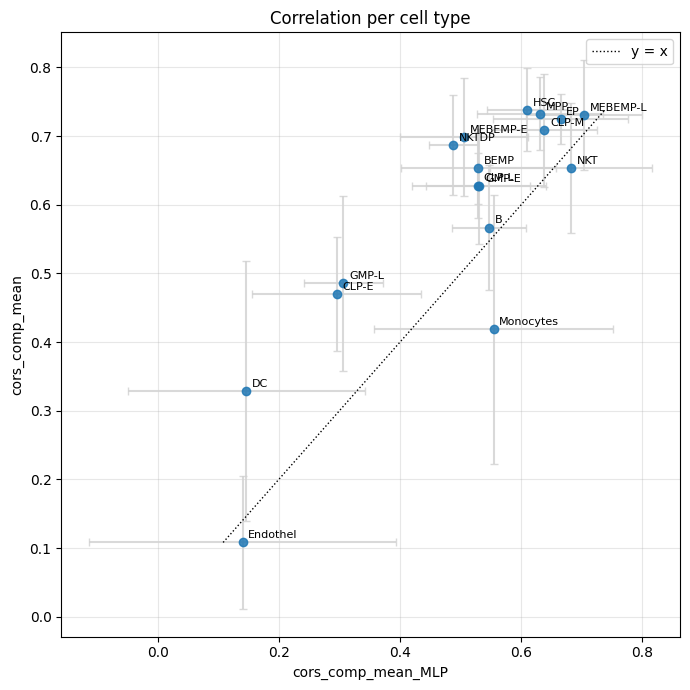

In [6]:

# 3) compute SEM and 95% CI (using normal approx; adjust if n small)
for m in metrics:
    mean_col = f"{m}_mean"
    std_col = f"{m}_std"
    cnt_col = f"{m}_count"
    sem_col = f"{m}_sem"
    ci_lo = f"{m}_95ci_lower"
    ci_hi = f"{m}_95ci_upper"

    # SEM: std / sqrt(n) (if count is 0, result becomes NaN)
    agg_linear[sem_col] = agg_linear[std_col] / np.sqrt(agg_linear[cnt_col].replace(0, np.nan))

    # 95% CI using 1.96 * SEM (normal approx)
    agg_linear[ci_lo] = agg_linear[mean_col] - 1.96 * agg_linear[sem_col]
    agg_linear[ci_hi] = agg_linear[mean_col] + 1.96 * agg_linear[sem_col]

# Example: show the table
print(agg_linear.head())


# python
# Plot error-scatter between two dataframes (agg, agg_linear) for cell-type correlations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Helper: try to find error columns for a mean column ----------
def _find_error_columns(df, mean_col):
    """
    Given df and mean_col (e.g., 'clr_cor_t_mean'), try to find:
      - symmetric error column (std or sem) -> returns ('sym', colname) or None
      - asymmetric CI columns (lower, upper) -> returns ('asym', (low_col, up_col)) or None
    """
    # candidates for symmetric error
    sym_candidates = [
        mean_col.replace('_mean', '_std'),
        mean_col.replace('_mean', '_sem'),
        mean_col + '_std',
        mean_col + '_sem'
    ]
    for c in sym_candidates:
        if c in df.columns:
            return ('sym', c)

    # candidates for asymmetric CI (lower/upper)
    low_candidates = [
        mean_col.replace('_mean', '_95ci_lower'),
        mean_col.replace('_mean', '_ci_lower'),
        mean_col + '_95ci_lower',
    ]
    up_candidates = [
        mean_col.replace('_mean', '_95ci_upper'),
        mean_col.replace('_mean', '_ci_upper'),
        mean_col + '_95ci_upper',
    ]
    for low in low_candidates:
        for up in up_candidates:
            if low in df.columns and up in df.columns:
                return ('asym', (low, up))

    # nothing found
    return (None, None)

def _get_errors_from_df(df, mean_col):
    """
    Returns either:
      - None, None if no error info
      - symmetric_errors (1d numpy array), None
      - None, asymmetric_errors (2 x N numpy array: [lower, upper])
    Lower/upper are positive distances from the mean.
    """
    typ, col = _find_error_columns(df, mean_col)
    mean_vals = df[mean_col].to_numpy(dtype=float)

    if typ == 'sym':
        sym = df[col].to_numpy(dtype=float)
        # Ensure non-negative
        sym = np.maximum(sym, 0.0)
        return sym, None
    elif typ == 'asym':
        low_col, up_col = col
        low = df[low_col].to_numpy(dtype=float)
        up = df[up_col].to_numpy(dtype=float)
        # Convert to distances from mean (in case columns were absolute bounds)
        lower_err = np.clip(mean_vals - low, 0.0, None)
        upper_err = np.clip(up - mean_vals, 0.0, None)
        return None, np.vstack([lower_err, upper_err])
    else:
        return None, None

# ---------- Main plotting function ----------
def plot_error_scatter(agg, agg_linear,
                       mean_col1='clr_cor_t_mean',
                       mean_col2='cors_clr_comp_mean',
                       celltype_col='celltype',
                       title='Correlation per cell type',
                       annotate=True,
                       figsize=(7,7),
                       savepath=None):
    """
    Merge agg and agg_linear on celltype_col and plot mean_col1 (x) vs mean_col2 (y)
    with error bars if available.
    Returns merged DataFrame and the matplotlib Figure.
    """
    # merge
    merged = pd.merge(agg, agg_linear, on=celltype_col, how='inner', suffixes=('_pytorch','_analytical'))
    if mean_col1 not in merged.columns:
        raise KeyError(f"{mean_col1} not found in merged dataframe columns: {merged.columns.tolist()}")
    if mean_col2 not in merged.columns:
        raise KeyError(f"{mean_col2} not found in merged dataframe columns: {merged.columns.tolist()}")

    # drop rows with NaN in mean cols
    merged = merged.dropna(subset=[mean_col1, mean_col2]).reset_index(drop=True)

    x = merged[mean_col1].to_numpy(dtype=float)
    y = merged[mean_col2].to_numpy(dtype=float)

    # errors for x and y (symmetric or asymmetric)
    x_sym, x_asym = _get_errors_from_df(merged, mean_col1)
    y_sym, y_asym = _get_errors_from_df(merged, mean_col2)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    # Choose errorbar parameters depending on availability
    err_kwargs = {}
    if x_asym is not None:
        err_kwargs['xerr'] = x_asym
    elif x_sym is not None:
        err_kwargs['xerr'] = x_sym
    if y_asym is not None:
        err_kwargs['yerr'] = y_asym
    elif y_sym is not None:
        err_kwargs['yerr'] = y_sym

    # Basic scatter with error bars (if any)
    ax.errorbar(x, y, fmt='o', ecolor='lightgray', alpha=0.85, capsize=3, markersize=6, **err_kwargs)

    # diagonal and fit line
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    low = min(xmin, ymin)
    high = max(xmax, ymax)
    line_x = np.linspace(low, high, 200)
    ax.plot(line_x, line_x, color='k', linestyle=':', linewidth=1, label='y = x')
    # if not np.isnan(m):
    #     ax.plot(line_x, m*line_x + b, color='C1', linestyle='--', linewidth=1, label=f'fit: y={m:.2f}x+{b:.2f}')

    # annotations
    if annotate:
        for xi, yi, label in zip(x, y, merged[celltype_col].astype(str)):
            ax.annotate(label, (xi, yi), xytext=(4, 3), textcoords='offset points', fontsize=8)
    if mean_col1 in (['clr_cor_t_mean', 'clr_r2_t_mean']):
        ax.set_xlabel("MLP_Pseudobulk")
    else:
        ax.set_xlabel(mean_col1)

    if mean_col2 in (['cors_clr_comp_mean', 'Rsq_clr_comp_mean']):
        ax.set_ylabel("Regression")
    else:
        ax.set_ylabel(mean_col2)
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    # show pearson text
    # ax.text(0.02, 0.98, pearson_text, transform=ax.transAxes, va='top', fontsize=9)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300)

    return merged, fig

# ---------- Example usage ----------
merged_df, fig = plot_error_scatter(df, agg_linear,
                                   mean_col1='cors_comp_mean_MLP',
                                   mean_col2='cors_comp_mean',
                                   celltype_col='celltype',
                                   title='Correlation per cell type',
                                   annotate=True,
                                   savepath=None)
plt.show()

   fold celltype  cors_comp
0     0        B   0.644776
1     0     BEMP   0.687946
2     0    CLP-E   0.438066
3     0    CLP-L   0.624261
4     0    CLP-M   0.735733


/tmp/ipykernel_3360245/98363341.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row[m] = fitting_res_dict[m][i]


In [14]:
agg_linear

,celltype,cors_comp_mean,cors_comp_std,cors_comp_count
0,B,0.566874,0.091041,5
1,BEMP,0.653459,0.052678,5
2,CLP-E,0.470071,0.083666,5
3,CLP-L,0.627940,0.047539,5
4,CLP-M,0.708376,0.082376,5
5,DC,0.328652,0.188879,5
6,EP,0.724850,0.036450,5
7,Endothel,0.108185,0.097309,5
8,GMP-E,0.626732,0.084089,5
9,GMP-L,0.485355,0.128155,5


In [18]:
df['celltype'] = agg_linear['celltype']

,fold_1,fold_2,fold_3,fold_4,fold_5,mean,std,celltype
0,0.646808,0.497631,0.553260,0.417027,0.527781,0.528501,0.074819,B
1,0.441457,0.595693,0.330259,0.401079,0.517543,0.457206,0.092014,BEMP
2,0.277902,0.081107,0.376985,0.315078,0.342404,0.278695,0.104005,CLP-E
3,0.629279,0.496625,0.385063,0.535189,0.439440,0.497119,0.083426,CLP-L
4,0.756828,0.644073,0.580581,0.788241,0.531579,0.660261,0.098868,CLP-M
5,0.508059,0.267790,-0.014122,0.063317,0.017602,0.168529,0.196134,DC
6,0.841282,0.589103,0.580488,0.557264,0.602315,0.634090,0.104630,EP
7,0.172854,0.335241,0.169494,0.053450,-0.324900,0.081228,0.222000,Endothel
8,0.515140,0.512130,0.330251,0.449461,0.600678,0.481532,0.089639,GMP-E
9,0.172954,0.255073,0.289538,0.338083,0.268999,0.264930,0.053908,GMP-L


In [ ]:

cor_list = []
for jf in glob.glob("kfold_results/fold_*_gpu_*.json"):
    with open(jf) as f:
        # print(json.load(f))
        d = json.load(f)
        cor_list.append(d['cor_list'])

In [25]:
import torch
model = torch.load(os.path.join("kfold_results", "fold_1_model.pt"), map_location='cuda', weights_only = False)
# model = ckpt["model"].to(device).eval()

In [26]:
model = model.eval()
list(model.parameters())

[Parameter containing:
 tensor([[ 5.0375e-03,  7.7324e-03, -3.6676e-03,  ...,  1.9121e-03,
          -2.3948e-03,  1.1028e-03],
         [-4.0195e-03,  1.1345e-03,  1.4629e-03,  ..., -2.4222e-03,
          -5.5244e-03, -3.0117e-03],
         [ 4.3605e-03, -2.9723e-03,  4.3372e-03,  ...,  3.5024e-03,
          -7.5627e-04, -1.3283e-03],
         ...,
         [-3.0854e-03, -4.7916e-03, -4.3050e-03,  ..., -7.6904e-03,
           2.4377e-03,  2.1110e-03],
         [ 3.6399e-04,  4.4204e-03,  4.6114e-03,  ..., -5.6783e-03,
           6.4398e-03, -2.6980e-03],
         [ 1.9770e-04,  7.2750e-03, -4.6650e-03,  ...,  2.8740e-05,
           1.3454e-03, -7.1458e-03]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([ 0.0088,  0.0054, -0.0045, -0.0067, -0.0036, -0.0068,  0.0003,  0.0048,
          0.0035,  0.0005, -0.0014,  0.0073, -0.0041, -0.0038,  0.0007, -0.0019,
          0.0080], device='cuda:0', requires_grad=True)]

In [ ]:
# for trying to automate passing keyword arguments

from dataclasses import asdict
import inspect

def call_with_cfg(fn, dc, **overrides):
    # Build a kwargs dict from dataclass + any overrides
    cfg = {**asdict(dc), **overrides}
    # Filter unexpected keys using the function’s signature
    sig = inspect.signature(fn)
    allowed = set(sig.parameters.keys())
    filtered = {k: v for k, v in cfg.items() if k in allowed}
    return fn(**filtered)
    

In [ ]:
import inspect

def instantiate(cls_or_fn, cfg: dict):
    # Filter cfg to only accepted kwargs of cls_or_fn
    sig = inspect.signature(cls_or_fn)
    allowed = set(sig.parameters.keys())
    filtered = {k: v for k, v in cfg.items() if k in allowed}
    return cls_or_fn(**filtered)

# Example: build Preprocessor and CellPredictor from config dataclasses
pre = instantiate(Preprocessor, asdict(pre_cfg))
cell_pred = instantiate(CellPredictor, asdict(model_cfg.predictor))
model = instantiate(CompositionModel, {**asdict(model_cfg), "preprocessor": pre, "cell_predictor": cell_pred})


In [ ]:
from dataclasses import asdict
import inspect

def call_with_cfg(fn, dc, **overrides):
    # Build a kwargs dict from dataclass + any overrides
    cfg = {**asdict(dc), **overrides}
    # Filter unexpected keys using the function’s signature
    sig = inspect.signature(fn)
    allowed = set(sig.parameters.keys())
    filtered = {k: v for k, v in cfg.items() if k in allowed}
    return fn(**filtered)

# Assuming build_datasets_from_indices expects Xs_raw, Z, Y_imp_ilr, cell_type_proportions_df, indices, method, dtype
datasets, extras = call_with_cfg(
    build_datasets_from_indices,
    data,                             # DataInputs dataclass
    method=method,
    indices=fold_idxs,
    dtype=torch.float32,
)


In [ ]:
def build_datasets_from_indices(
    method: str,
    Xs_raw, Z, Y_imp_ilr, cell_type_proportions_df,
    indices: dict,
    dtype: torch.dtype = torch.float32,
):
    # ... same body as you have, selecting rows with indices['train'], ['val'], ['test'] ...
    return datasets, extras

In [ ]:
datasets, extras = build_datasets_from_indices(**asdict(data), method=method, indices=fold_idxs, dtype=torch.float32)

In [ ]:
def run_one_fold(data: DataInputs, pre_cfg: PreprocessorConfig, model_cfg: ModelConfig,
                 trainer_cfg: TrainerConfig, fold: int, fold_idxs: dict) -> dict:
    # Datasets/loaders from DataInputs without manual mapping
    datasets, extras = call_with_cfg(build_datasets_from_indices, data, method=model_cfg.method, indices=fold_idxs, dtype=torch.float32)
    loaders = build_loaders(datasets, batch_size=trainer_cfg.batch_size, num_workers=2,
                            pin_memory=True, collate_fn=collate_samples_compact)
    loader, loader_val, loader_test = loaders["train"], loaders["val"], loaders["test"]

    # Derive fold-specific values
    gene_mean, gene_std = compute_cellwise_stats(loader, device="cpu")
    gene_mask = (gene_std > 1e-6)
    G_kept = int(gene_mask.sum().item())
    C = int(np.asarray(data.Z).shape[1])
    out_features = (data.Y_imp_ilr.shape[1] if model_cfg.method.endswith("ilr")
                    else int(np.asarray(data.cell_type_proportions_df).shape[1]))
    in_features = G_kept + C
    age_col = data.Z.columns.tolist().index("ages")
    cont_mask = torch.zeros(C, dtype=torch.bool); cont_mask[age_col] = True
    train_idx = fold_idxs["train"]
    age_mean = torch.tensor([float(data.Z.iloc[train_idx]["ages"].mean())], dtype=torch.float32)
    age_std  = torch.tensor([float(max(data.Z.iloc[train_idx]["ages"].std(), 1e-8))], dtype=torch.float32)

    # Update configs
    pre_cfg = replace(pre_cfg, gene_mask=gene_mask,
                      gene_mean=gene_mean[gene_mask], gene_std=gene_std[gene_mask],
                      cont_cov_mask=cont_mask, cov_mean=age_mean, cov_std=age_std)
    model_cfg = replace(model_cfg, in_features=in_features, out_features=out_features)
    model_cfg.predictor = replace(model_cfg.predictor, in_features=in_features, out_features=out_features)

    # Instantiate components using filtered configs
    pre       = instantiate(Preprocessor, asdict(pre_cfg))
    cell_pred = instantiate(CellPredictor, asdict(model_cfg.predictor))
    model     = instantiate(CompositionModel, {**asdict(model_cfg), "preprocessor": pre, "cell_predictor": cell_pred})

    trainer = Trainer(model, loaders["train"], loaders["val"],
                      lr=trainer_cfg.lr, weight_decay=trainer_cfg.weight_decay,
                      epochs=trainer_cfg.epochs, recenter_y=trainer_cfg.recenter_y,
                      device=trainer_cfg.device, dtype=model_cfg.predictor.dtype, verbose=trainer_cfg.verbose)
    trainer.fit()

    test_res = evaluate_on_loader(trainer.model, loader_test, device=trainer_cfg.device,
                                  recenter_y=trainer_cfg.recenter_y, y_mean=trainer.y_mean,
                                  return_compositions=False, method=model_cfg.method)
    from torch.nn.functional import mse_loss
    test_mse = mse_loss(test_res["preds"], test_res["targets"], reduction="mean").item()
    return {"fold": fold, "test_mse": test_mse, "trainer": trainer}